In [3]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np

# Load the dataset


df = pd.read_csv("jena_climate_2009_2016.csv")

In [4]:
df = df[5::6]  # Downsampling by taking every 6th value starting from the 5th
df.index = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
temp = df['T (degC)']

In [5]:
# Defined the custom loss function
def custom_loss(y_true, y_pred, lambda_=0.2 , lambda_2 = 2.25):
    # Prediction error (MSE)
    pred_error = tf.reduce_mean(tf.square(y_true - y_pred))
    
    # Smoothness penalty (absolute difference between consecutive predictions)
    smoothness_penalty = tf.reduce_mean(tf.abs(y_pred[1:] - y_pred[:-1]))
    
    # Combined loss
    return lambda_2*pred_error + lambda_ * smoothness_penalty

In [6]:
temp_df = pd.DataFrame({'Temperature':temp})
temp_df['Seconds'] = temp_df.index.map(pd.Timestamp.timestamp)
temp_df.head()


,Temperature,Seconds
Date Time,,
2009-01-01 01:00:00,-8.05,1.230772e+09
2009-01-01 02:00:00,-8.88,1.230775e+09
2009-01-01 03:00:00,-8.81,1.230779e+09
2009-01-01 04:00:00,-9.05,1.230782e+09
2009-01-01 05:00:00,-9.63,1.230786e+09


In [7]:
day = 60*60*24
year = 365.2425*day

temp_df['Day sin'] = np.sin(temp_df['Seconds'] * (2* np.pi / day))
temp_df['Day cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / day))
temp_df['Year sin'] = np.sin(temp_df['Seconds'] * (2 * np.pi / year))
temp_df['Year cos'] = np.cos(temp_df['Seconds'] * (2 * np.pi / year))
temp_df.head()

,Temperature,Seconds,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 01:00:00,-8.05,1.230772e+09,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,-8.88,1.230775e+09,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,-8.81,1.230779e+09,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,-9.05,1.230782e+09,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,-9.63,1.230786e+09,0.965926,0.258819,0.012916,0.999917


In [8]:
temp_df = temp_df.drop('Seconds', axis=1)
temp_df.head()


,Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,
2009-01-01 01:00:00,-8.05,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,-8.88,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,-8.81,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,-9.05,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,-9.63,0.965926,0.258819,0.012916,0.999917


In [9]:
p_temp_df = pd.concat([df['p (mbar)'], temp_df], axis=1)
p_temp_df.head()

,p (mbar),Temperature,Day sin,Day cos,Year sin,Year cos
Date Time,,,,,,
2009-01-01 01:00:00,996.50,-8.05,0.258819,0.965926,0.010049,0.999950
2009-01-01 02:00:00,996.62,-8.88,0.500000,0.866025,0.010766,0.999942
2009-01-01 03:00:00,996.84,-8.81,0.707107,0.707107,0.011483,0.999934
2009-01-01 04:00:00,996.99,-9.05,0.866025,0.500000,0.012199,0.999926
2009-01-01 05:00:00,997.46,-9.63,0.965926,0.258819,0.012916,0.999917


In [10]:
def df_to_X_y2(df, window_size=7):
  df_as_np = df.to_numpy()
  X = []
  y = []
  for i in range(len(df_as_np)-window_size):
    row = [r for r in df_as_np[i:i+window_size]]
    X.append(row)
    label = df_as_np[i+window_size][1]
    y.append(label)
  return np.array(X), np.array(y)

In [11]:
X2, y2 = df_to_X_y2(p_temp_df)
X2.shape, y2.shape

((70084, 7, 6), (70084,))

In [12]:
X2_train, y2_train = X2[:60000], y2[:60000]
X2_val, y2_val = X2[60000:65000], y2[60000:65000]
X2_test, y2_test = X2[65000:], y2[65000:]
X2_train.shape, y2_train.shape, X2_val.shape, y2_val.shape, X2_test.shape, y2_test.shape

((60000, 7, 6), (60000,), (5000, 7, 6), (5000,), (5084, 7, 6), (5084,))

In [13]:
p_training_mean2 = np.mean(X2_train[:, :, 0])
p_training_std2 = np.std(X2_train[:, :, 0])

temp_training_mean2 = np.mean(X2_train[:, :, 1])
temp_training_std2 = np.std(X2_train[:, :, 1])

def preprocess2(X):
  X[:, :, 0] = (X[:, :, 0] - p_training_mean2) / p_training_std2
  X[:, :, 1] = (X[:, :, 1] - temp_training_mean2) / temp_training_std2

In [14]:
preprocess2(X2_train)
preprocess2(X2_val)
preprocess2(X2_test)


In [15]:
def preprocess_output2(y):
  
  y = (y - temp_training_mean2) / temp_training_std2
  return y

In [16]:
preprocess_output2(y2_train)
preprocess_output2(y2_val)
preprocess_output2(y2_test)

array([ 0.41245076,  0.35368268,  0.32312327, ..., -1.43051636,
       -1.44697142, -1.56920903])

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanAbsoluteError
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [18]:
model2 = Sequential()
model2.add(InputLayer((7, 6)))
model2.add(LSTM(64))
model2.add(Dense(8, 'relu'))
model2.add(Dense(1, 'linear'))

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,705 (73.07 KB)

 Trainable params: 18,705 (73.07 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model2.compile(loss=custom_loss, optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [20]:
model2.fit(X2_train, y2_train, validation_data=(X2_val, y2_val), epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - loss: 217.7878 - root_mean_squared_error: 9.6645 - val_loss: 11.3778 - val_root_mean_squared_error: 2.2386
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 19.0324 - root_mean_squared_error: 2.7680 - val_loss: 5.9169 - val_root_mean_squared_error: 1.6076
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 8.4918 - root_mean_squared_error: 1.7170 - val_loss: 3.2155 - val_root_mean_squared_error: 1.1763
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 5.4025 - root_mean_squared_error: 1.2525 - val_loss: 2.0947 - val_root_mean_squared_error: 0.9390
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 4.2447 - root_mean_squared_error: 1.0196 - val_loss: 1.5135 - val_root_mean_squared_error: 0.7883
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 3.6284 - root_mean_squared_error: 0.8751 - val_loss: 1.2284 - val_root_mean_squared_error: 0.7019
Epoch 7/50
1875/1875 ━━━━━━━━━

In [21]:
y2_pred = model2.predict(X2_test)
y2_pred

159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[12.91742  ],
       [12.450027 ],
       [11.975418 ],
       ...,
       [-1.6578183],
       [-3.1276915],
       [-3.0873685]], dtype=float32)

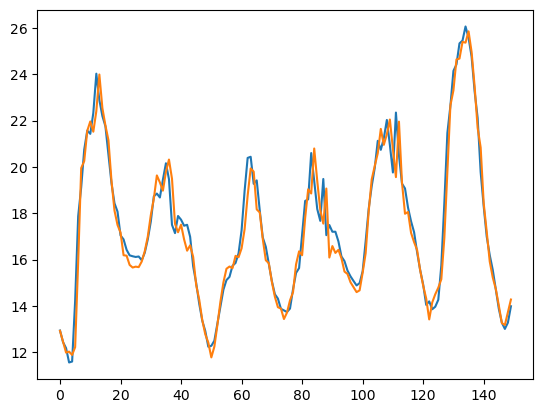

In [22]:
import matplotlib.pyplot as plt
plt.plot(y2_test[:150])
plt.plot(y2_pred[:150])

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y2_test, y2_pred)
mse = mean_squared_error(y2_test, y2_pred)
rmse = np.sqrt(mse)

print("Test Set Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Test Set Performance:
Mean Absolute Error (MAE): 0.45856769118343726
Mean Squared Error (MSE): 0.4397248227502278
Root Mean Squared Error (RMSE): 0.6631175029738152


In [24]:
from sklearn.metrics import r2_score

# Calculate the R-squared score
r2 = r2_score(y2_test, y2_pred)

print("R-squared (R2) Score:", r2)


R-squared (R2) Score: 0.993686394346268


In [25]:
100*(0.9933574229204819- 0.9931023386508809)

0.02550842696009692

In [26]:
model2.save('my_model_multivariate.h5')

In [27]:
from tensorflow.keras.models import load_model
loaded_model = load_model('my_model_multivariate.h5', custom_objects={'custom_loss': custom_loss})

In [28]:
loaded_model.predict(X2_test)

159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


array([[12.91742  ],
       [12.450027 ],
       [11.975418 ],
       ...,
       [-1.6578183],
       [-3.1276915],
       [-3.0873685]], dtype=float32)